<center>HW8 DeFi EDA: 1inch DEX Aggregator </center>
<center> Sergey Protasov</center>

**Protocol**: 1inch which is the DEX aggregator. </br>
**Category**: aggregators so I will compare mostly with CowSwap, ParaSwap protocols. </br>
**Tools used**: 
1. `Etherscan`
2. `The Graph`
3. `DeFiLlama`
4. `CoinGecko`
5. `Dune`

## 0. Setup

In [1]:
%pip install web3 dune-client requests pandas numpy matplotlib nbformat plotly

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os, time
from datetime import datetime

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from web3 import Web3

plt.style.use('ggplot')
plt.rcParams.update({'font.size': 12, 'figure.figsize': (12, 5)})
pd.reset_option('display.float_format')

ETH_HTTP_NODE     = os.environ.get('ETH_HTTP_NODE',     '')
ETHERSCAN_API_KEY = os.environ.get('ETHERSCAN_API_KEY', '')
THEGRAPH_API_KEY  = os.environ.get('THEGRAPH_API_KEY',  '')
DUNE_API_KEY      = os.environ.get('DUNE_API_KEY',      '')

ROUTER_V6  = '0x111111125421ca6dc452d289314280a0f8842a65'
INCH_TOKEN = '0x111111111117dC0aa78b770fA6A738034120C302'
WETH       = '0xC02aaA39b223FE8D0A0e5C4F27eAD9083C756Cc2'
USDC       = '0xA0b86991c6218b36c1d19D4a2e9Eb0cE3606eB48'

ONEINCH_SUBGRAPH_ID = '4PL3bC4QYRDDf3gFr54otrXUigkgKUPdffK2ManakvVa'
GRAPH_URL = f'https://gateway.thegraph.com/api/{THEGRAPH_API_KEY}/subgraphs/id/{ONEINCH_SUBGRAPH_ID}'


if (not ETH_HTTP_NODE) or (not ETHERSCAN_API_KEY) or (not THEGRAPH_API_KEY) or (not DUNE_API_KEY):
    print('Error: missing environment variables, please set ETH_HTTP_NODE, ETHERSCAN_API_KEY, THEGRAPH_API_KEY, and DUNE_API_KEY.')
    

## 1. Etherscan

The 1INCH ERC-20 token is used for DAO governance and resolving Fusion orders.
The code will fetch the last 10,000 transfers to analyze:
- Transfer size distribution
- Daily volume and transaction count trends
- Top sending or receiving addresses

In [3]:
BASE_ES = 'https://api.etherscan.io/v2/api'

def etherscan(**params):
    params['chainid'] = 1
    params['apikey']  = ETHERSCAN_API_KEY
    return requests.get(BASE_ES, params=params, timeout=20).json()

try:
    resp = etherscan(module='account', action='tokentx',
                     contractaddress=INCH_TOKEN, page=1, offset=10_000, sort='desc')
    inch_tx = pd.DataFrame(resp.get('result', []))
    inch_tx['timeStamp']   = pd.to_datetime(inch_tx['timeStamp'].astype(int), unit='s')
    inch_tx['value_1inch'] = inch_tx['value'].astype(float) / 1e18
    print(f'Transfers fetched: {len(inch_tx)}')
    print(f'Date range: {inch_tx["timeStamp"].min().date()} -> {inch_tx["timeStamp"].max().date()}')

    inch_tx[['timeStamp','from','to','value_1inch']].head(6)
except Exception as e:
    print(f'Etherscan failed: {e}')

Transfers fetched: 10000
Date range: 2026-04-14 -> 2026-05-01


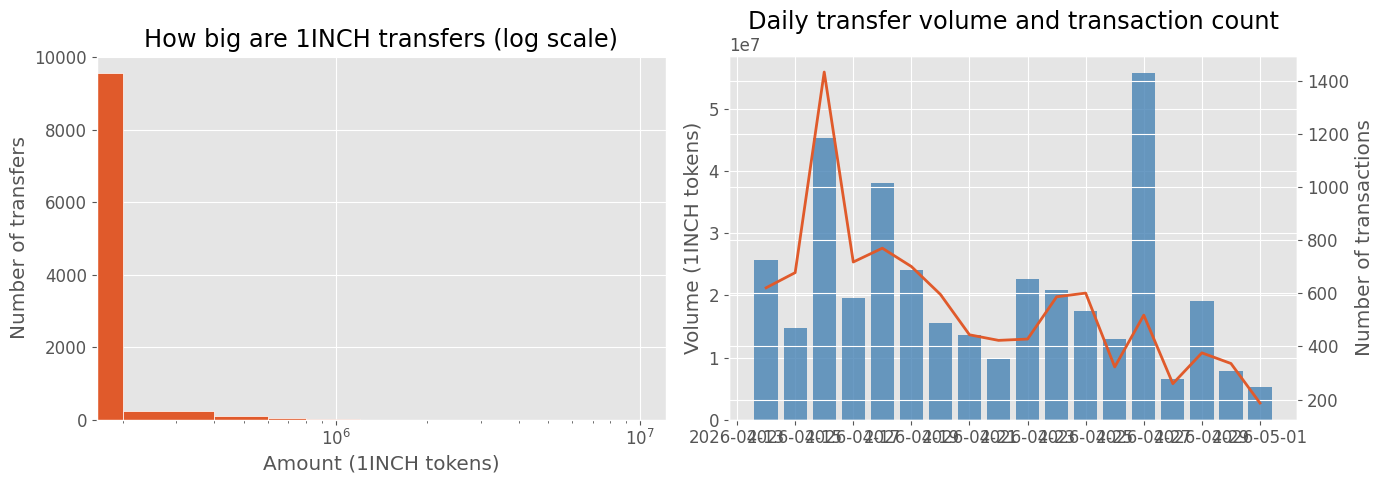

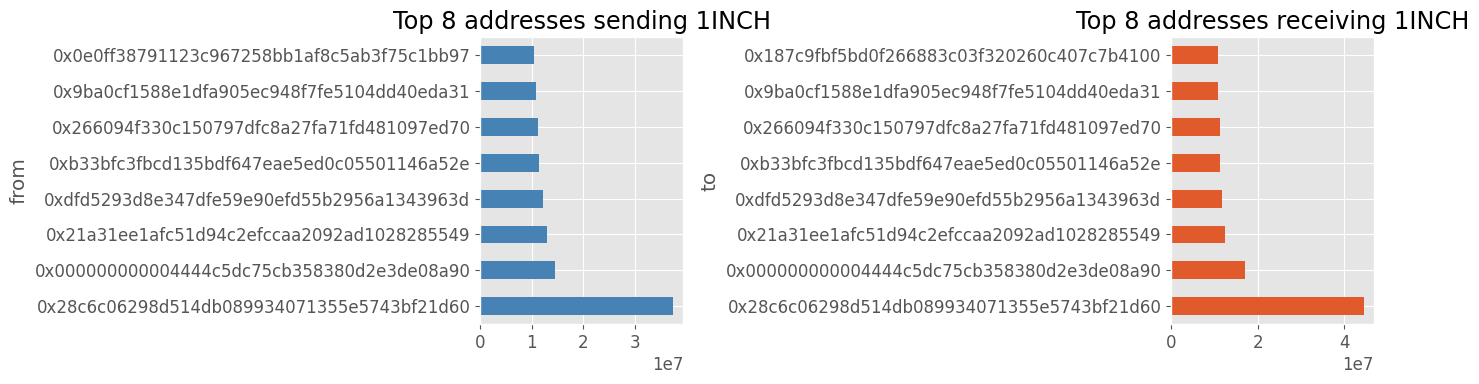

Router V6 last transaction: 2026-05-01 12:53:35  (liveness confirmed)


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

inch_tx['value_1inch'].replace(0, np.nan).dropna().hist(
    bins=50, ax=axes[0], color='#E05A2B', edgecolor='white')
axes[0].set_xscale('log')
axes[0].set_title('How big are 1INCH transfers (log scale)')
axes[0].set_xlabel('Amount (1INCH tokens)')
axes[0].set_ylabel('Number of transfers')

daily_es = inch_tx.set_index('timeStamp').resample('D')['value_1inch'].agg(['sum', 'count'])
vol_ax = axes[1]
vol_ax.bar(daily_es.index, daily_es['sum'], color='#4682B4', alpha=0.8)
tx_ax = vol_ax.twinx()
tx_ax.plot(daily_es.index, daily_es['count'], color='#E05A2B', linewidth=2)
vol_ax.set_title('Daily transfer volume and transaction count')
vol_ax.set_ylabel('Volume (1INCH tokens)')
tx_ax.set_ylabel('Number of transactions')
plt.tight_layout()
plt.show()

top_from = inch_tx.groupby('from')['value_1inch'].sum().sort_values(ascending=False).head(8)
top_to   = inch_tx.groupby('to')['value_1inch'].sum().sort_values(ascending=False).head(8)
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 4))
top_from.plot(kind='barh', ax=axes2[0], color='#4682B4')
axes2[0].set_title('Top 8 addresses sending 1INCH')
top_to.plot(kind='barh', ax=axes2[1], color='#E05A2B')
axes2[1].set_title('Top 8 addresses receiving 1INCH')
plt.tight_layout()
plt.show()

try:
    resp2 = etherscan(module='account', action='txlist',
                      address=ROUTER_V6, page=1, offset=1, sort='desc')
    last_ts = pd.to_datetime(int(resp2['result'][0]['timeStamp']), unit='s')
    print(f'Router V6 last transaction: {last_ts}  (liveness confirmed)')
except Exception as e:
    print(f'Router liveness check: {e}')

## 2. The Graph

The 1INCH airdrop subgraph on The Graph indexes all on-chain Claimed events from the 1inch airdrop contracts, recording every wallet address and the exact amount of 1INCH they received.

So we wanna know how concentrated or decentralized was the initial 1INCH token distribution.

> Subgraph: `4PL3bC4QYRDDf3gFr54otrXUigkgKUPdffK2ManakvVa`

In [5]:
def graph_query(query):
    resp = requests.post(GRAPH_URL, json={'query': query}, timeout=30)
    resp.raise_for_status()
    data = resp.json()
    if 'errors' in data:
        raise ValueError(data['errors'])
    return data['data']

all_claims = []
last_index = -1
while True:
    q = f'''{{
      claims(first: 1000, orderBy: index, orderDirection: asc,
             where: {{index_gt: {last_index}}}) {{
        index account amount version
      }}
    }}'''
    page = graph_query(q)['claims']
    if not page:
        break
    all_claims.extend(page)
    last_index = int(page[-1]['index'])
    if len(page) < 1000:
        break

claims_df = pd.DataFrame(all_claims)
claims_df['amount_1inch'] = claims_df['amount'].astype(float) / 1e18
claims_df['version']      = claims_df['version'].astype(int)
claims_df['index']        = claims_df['index'].astype(int)

print(f'Total claims fetched:  {len(claims_df)}')
print(f'Total 1INCH airdropped: {claims_df["amount_1inch"].sum()/1e6}M tokens')
print(f'Airdrop versions: {claims_df["version"].value_counts().to_dict()}')
print(f'Median claim:  {claims_df["amount_1inch"].median()} 1INCH')
print(f'Mean claim:    {claims_df["amount_1inch"].mean()} 1INCH')
print(f'Max claim:     {claims_df["amount_1inch"].max()/1e6}M 1INCH')

claims_df[['index','account','amount_1inch','version']].head(5)

Total claims fetched:  70071
Total 1INCH airdropped: 95.03984613340458M tokens
Airdrop versions: {1: 43942, 2: 26129}
Median claim:  609.0713008281621 1INCH
Mean claim:    1356.3363750111257 1INCH
Max claim:     9.74968600328706M 1INCH


,index,account,amount_1inch,version
0,0,0x0000000000f485a774ee60343ad3ac6d05d95fba,393.290347,2
1,1,0x00000000034b55ebd82cde9b38a85ab0978b7a47,616.020947,2
2,2,0x000000004fa9e635dbe91c83aee357d01494936d,744.383889,1
3,2,0x000000007cb2bd00ae5eb839930bb7847ae5b039,647.713106,2
4,3,0x0000001e7d4df5b43cb89f7997685a85dd535c2b,1033.423180,2


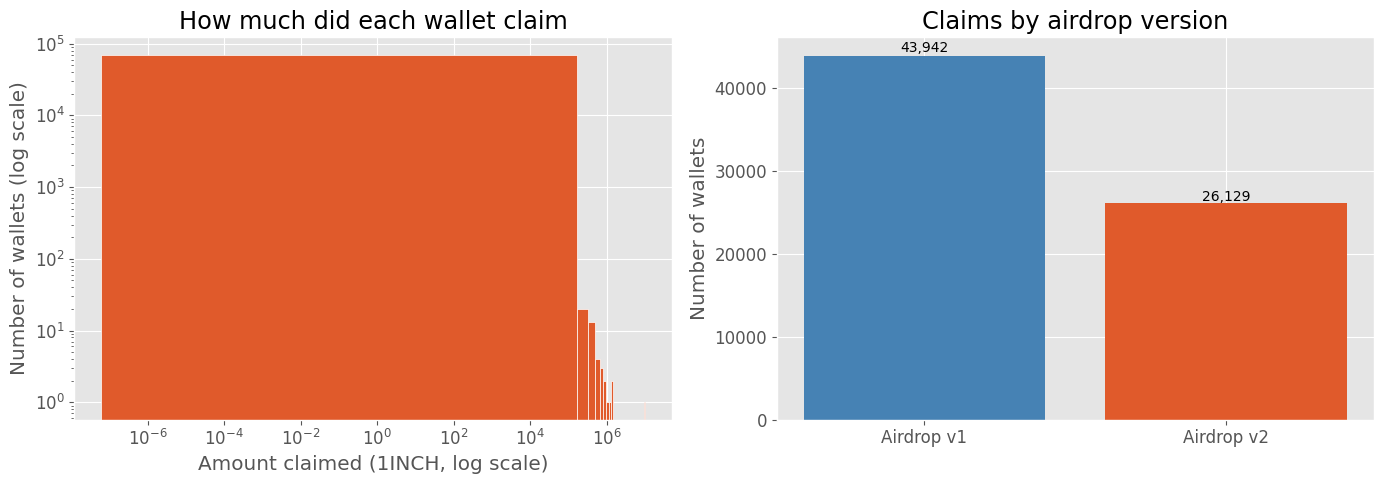

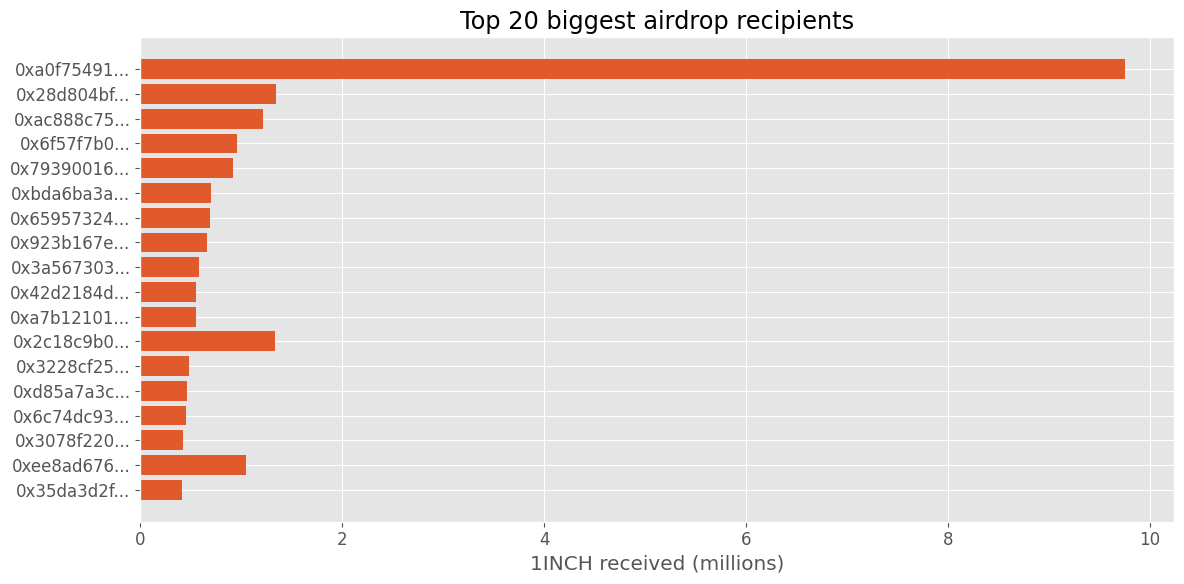

Top 1% of claimants (700 wallets) received 52.6% of airdropped tokens
Gini-like: top 10 recipients hold 19.6% of airdropped supply


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

claims_df['amount_1inch'].replace(0, np.nan).dropna().hist(
    bins=60, ax=axes[0], color='#E05A2B', edgecolor='white', log=True)
axes[0].set_xscale('log')
axes[0].set_title('How much did each wallet claim')
axes[0].set_xlabel('Amount claimed (1INCH, log scale)')
axes[0].set_ylabel('Number of wallets (log scale)')

ver_counts = claims_df['version'].value_counts().sort_index()
axes[1].bar([f'Airdrop v{v}' for v in ver_counts.index], ver_counts.values, color=['#4682B4', '#E05A2B'])
axes[1].set_title('Claims by airdrop version')
axes[1].set_ylabel('Number of wallets')
for i, (v, c) in enumerate(ver_counts.items()):
    axes[1].text(i, c + c*0.01, f'{c:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

top20 = claims_df.nlargest(20, 'amount_1inch')[['account', 'amount_1inch', 'version']]
top20['account_short'] = top20['account'].str[:10] + '...'

fig2, ax = plt.subplots(figsize=(12, 6))
ax.barh(top20['account_short'][::-1], top20['amount_1inch'][::-1] / 1e6, color='#E05A2B')
ax.set_xlabel('1INCH received (millions)')
ax.set_title('Top 20 biggest airdrop recipients')
plt.tight_layout()
plt.show()

n = len(claims_df)
top1pct = claims_df.nlargest(max(1, n // 100), 'amount_1inch')['amount_1inch'].sum()
total   = claims_df['amount_1inch'].sum()
print(f'Top 1% of claimants ({n//100} wallets) received {top1pct/total*100:.1f}% of airdropped tokens')
print(f'Gini-like: top 10 recipients hold {claims_df.nlargest(10,"amount_1inch")["amount_1inch"].sum()/total*100:.1f}% of airdropped supply')

## 3. DeFiLlama

DeFiLlama tracks DEX aggregator volume.
I want to compare 1inch against its three main alternatives:
- CowSwap — batch-auction or intent-based
- ParaSwap — same routing-algorithm category as 1inch

In [7]:
def llama_agg_summary(slug):
    url = f'https://api.llama.fi/summary/aggregators/{slug}'
    r = requests.get(url, timeout=20)
    if r.status_code != 200:
        return None, None
    data = r.json()
    if 'totalDataChart' not in data:
        return None, data
    df = pd.DataFrame(data['totalDataChart'], columns=['timestamp', 'volume'])
    df['date']   = pd.to_datetime(df['timestamp'], unit='s')
    df['volume'] = df['volume'].astype(float)
    return df, data

PROTOCOL_SLUGS = {'1inch': '1inch', 'cowswap': 'CowSwap',
                  'paraswap': 'ParaSwap'}
dfs  = {}
meta = {}

for slug, display in PROTOCOL_SLUGS.items():
    df, m = llama_agg_summary(slug)
    if df is not None:
        df['protocol'] = display
        dfs[slug]  = df
        meta[slug] = m
        print(f'{display:15s}  24h: ${m.get("total24h",0)/1e6}M  '
              f'7d: ${m.get("total7d",0)/1e6}M  '
              f'30d: ${m.get("total30d",0)/1e6}M')
    else:
        print(f'{display}: not found on DeFiLlama (slug "{slug}")')

if not dfs:
    print('DeFiLlama requests failed')

1inch            24h: $73.654123M  7d: $540.051198M  30d: $2899.382294M
CowSwap          24h: $78.618596M  7d: $500.083077M  30d: $4029.266294M
ParaSwap         24h: $93.73438M  7d: $519.868629M  30d: $2644.422597M


In [20]:
CUTOFF = pd.Timestamp.now() - pd.Timedelta(days=180)
COLORS = {'1inch':'#E05A2B', 'cowswap':'#4682B4', 'paraswap':'#2ECC71', '0x':'#9B59B6'}

fig = go.Figure()
for slug, df in dfs.items():
    recent = df[df['date'] >= CUTOFF]
    name = PROTOCOL_SLUGS.get(slug, slug)
    fig.add_trace(go.Scatter(x=recent['date'], y=recent['volume']/1e6, name=name,
                             mode='lines', line=dict(color=COLORS.get(slug, '#999'), width=2)))
fig.update_layout(title='Daily trading volume: 1inch vs competitors for last 6 months',
                  xaxis_title='Date', yaxis_title='Volume ($M)',
                  height=460, hovermode='x unified')
fig.show()

combined = pd.concat(dfs.values(), ignore_index=True)
combined = combined[combined['date'] >= CUTOFF]
pivot = combined.pivot_table(index='date', columns='protocol', values='volume', aggfunc='sum').fillna(0)
pivot['_total'] = pivot.sum(axis=1)
share = pivot.drop(columns='_total').div(pivot['_total'], axis=0) * 100
share = share.rolling(7).mean().dropna()

fig2 = go.Figure()
for col in share.columns:
    slug_key = next((k for k, v in PROTOCOL_SLUGS.items() if v == col), col.lower())
    fig2.add_trace(go.Scatter(x=share.index, y=share[col], name=col,
                              stackgroup='one', mode='none',
                              fillcolor=COLORS.get(slug_key, '#999')))
fig2.update_layout(title='Market share over time (7-day rolling average)',
                   yaxis_title='Share of total volume (%)', height=430, hovermode='x unified')
fig2.show()

kpi_rows = [{'Protocol': PROTOCOL_SLUGS.get(s, s),
             '24h Vol ($M)':  round(meta[s].get('total24h', 0)/1e6, 1),
             '7d Vol ($M)':   round(meta[s].get('total7d',  0)/1e6, 1),
             '30d Vol ($M)':  round(meta[s].get('total30d', 0)/1e6, 1),
             'Chains': len(meta[s].get('chains', []))} for s in meta]
kpi_df = pd.DataFrame(kpi_rows).sort_values('24h Vol ($M)', ascending=False)
print('Aggregator comparison (DeFiLlama)')
print('='*65)
print(kpi_df.to_string(index=False))

Aggregator comparison (DeFiLlama)
Protocol  24h Vol ($M)  7d Vol ($M)  30d Vol ($M)  Chains
ParaSwap          93.7        519.9        2644.4       9
 CowSwap          78.6        500.1        4029.3       8
   1inch          73.7        540.1        2899.4      14


## 4. CoinGecko

Here we wanna analyze the 1INCH governance token and compare it with COW (CowSwap) to understand how the market prices these two competing aggregator protocols. </br>
Also to cross-validate CoinGecko's aggregated price against Binance spot klines.

In [9]:
def cg_market_chart(coin_id, days=365):
    url = f'https://api.coingecko.com/api/v3/coins/{coin_id}/market_chart'
    r = requests.get(url, params={'vs_currency':'usd','days':days}, timeout=20)
    data = r.json()
    df = pd.DataFrame(data['prices'], columns=['ts','price'])
    df['datetime'] = pd.to_datetime(df['ts'], unit='ms')
    df['volume']   = [v[1] for v in data['total_volumes']]
    df['mcap']     = [v[1] for v in data['market_caps']]
    return df

inch_cg = cg_market_chart('1inch', days=365)
cow_cg  = cg_market_chart('cow-protocol', days=365)

print(f'1INCH  price: ${inch_cg["price"].iloc[-1]:.4f}  '
      f'MCap: ${inch_cg["mcap"].iloc[-1]/1e6:.0f}M  '
      f'24h vol: ${inch_cg["volume"].iloc[-1]/1e6:.0f}M')
print(f'COW    price: ${cow_cg["price"].iloc[-1]:.4f}  '
      f'MCap: ${cow_cg["mcap"].iloc[-1]/1e6:.0f}M  '
      f'24h vol: ${cow_cg["volume"].iloc[-1]/1e6:.0f}M')

kl = requests.get('https://api.binance.com/api/v3/klines',
                  params={'symbol':'1INCHUSDT','interval':'1d','limit':365}, timeout=20).json()
inch_bn = pd.DataFrame(kl, columns=['open_time','open','high','low','close','volume',
                                     'close_time','qav','trades','tbbav','tbqav','ignore'])
inch_bn['datetime'] = pd.to_datetime(inch_bn['open_time'], unit='ms')
for c in ['open','high','low','close','volume']:
    inch_bn[c] = inch_bn[c].astype(float)
print(f'Binance klines: {len(inch_bn)} daily candles')

1INCH  price: $0.0937  MCap: $132M  24h vol: $7M
COW    price: $0.1870  MCap: $104M  24h vol: $4M
Binance klines: 365 daily candles


In [23]:
inch_norm = inch_cg['price'] / inch_cg['price'].iloc[0] * 100
cow_norm  = cow_cg['price']  / cow_cg['price'].iloc[0]  * 100

fig_price_compare = go.Figure()
fig_price_compare.add_trace(go.Scatter(x=inch_cg['datetime'], y=inch_norm, name='1INCH',
                                       line=dict(color='#E05A2B', width=2)))
fig_price_compare.add_trace(go.Scatter(x=cow_cg['datetime'],  y=cow_norm,  name='COW',
                                       line=dict(color='#4682B4', width=2)))
fig_price_compare.add_hline(y=100, line_dash='dot', line_color='grey')
fig_price_compare.update_layout(title='1INCH vs COW token: 12-month price performance (Base = 100)',
                                yaxis_title='Indexed price (starts at 100)', height=430, hovermode='x unified')
fig_price_compare.show()

fig_mcap = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.08,
                         subplot_titles=('1INCH market cap over time', 'Daily trading turnover (Vol / MCap)'))
fig_mcap.add_trace(go.Scatter(x=inch_cg['datetime'], y=inch_cg['mcap']/1e6,
                               fill='tozeroy', line=dict(color='#E05A2B'), name='MCap'), 1, 1)
fig_mcap.add_trace(go.Scatter(x=inch_cg['datetime'],
                               y=inch_cg['volume'] / inch_cg['mcap'].replace(0, np.nan),
                               line=dict(color='#4682B4', width=1.5), name='Turnover'), 2, 1)
fig_mcap.update_yaxes(title_text='$M', row=1, col=1)
fig_mcap.update_yaxes(title_text='Vol / MCap', row=2, col=1)
fig_mcap.update_layout(height=520, showlegend=False, title='1INCH market cap and trading activity')
fig_mcap.show()

fig_crosscheck = go.Figure()
fig_crosscheck.add_trace(go.Scatter(x=inch_cg['datetime'], y=inch_cg['price'],
                                    name='CoinGecko (aggregated)', line=dict(color='#2ECC71')))
fig_crosscheck.add_trace(go.Scatter(x=inch_bn['datetime'], y=inch_bn['close'],
                                    name='Binance 1INCHUSDT', line=dict(color='#F39C12')))
fig_crosscheck.update_layout(title='1INCH price: CoinGecko vs Binance (data cross-check)',
                             xaxis_title='Date', yaxis_title='Price (USD)',
                             height=400, hovermode='x unified')
fig_crosscheck.show()

## 5. Dune

We wanna query weekly aggregator volume by protocol and visualize 1inch's routing destination breakdown.

Dune query ids:
- 7410292
- 7410340

Dune dashboard link:
- https://dune.com/protas/hw8

In [11]:
from dune_client.client import DuneClient
from dune_client.query import QueryBase

dune = DuneClient(DUNE_API_KEY)

DUNE_QUERY_ID = 7410292

df = None

try:
    result = dune.get_latest_result(DUNE_QUERY_ID)
    df = pd.DataFrame(result.result.rows)
except Exception as e:
    print(f'Dune query unavailable ({type(e).__name__}).')

pd.reset_option('display.float_format')
df

,project,rows
0,0x API,468229
1,1inch,217200
2,kyberswap,157231
3,bitget_dex_aggregator,145965
4,sushiswap,78699
5,cow_protocol,73376
6,velora,52253
7,bebop,40008
8,tokenlon,14918
9,odos,9201


In [12]:
DUNE_QUERY_ID = 7410340

agg_df = None

try:
    result = dune.get_latest_result(DUNE_QUERY_ID)
    
    agg_df = pd.DataFrame(result.result.rows)
except Exception as e:
    print(f'Dune query unavailable ({type(e).__name__}).')

pd.reset_option('display.float_format')
agg_df

,project,tx_count,volume_usd,week
0,cow_protocol,31678,3.812466e+08,2025-10-27 00:00:00.000 UTC
1,1inch,40404,3.346620e+08,2025-10-27 00:00:00.000 UTC
2,kyberswap,14979,1.950618e+08,2025-10-27 00:00:00.000 UTC
3,bebop,11040,1.834696e+08,2025-10-27 00:00:00.000 UTC
4,velora,5942,1.834263e+08,2025-10-27 00:00:00.000 UTC
...,...,...,...,...
284,bitget_dex_aggregator,28860,4.330073e+07,2026-04-27 00:00:00.000 UTC
285,tokenlon,2298,4.134054e+07,2026-04-27 00:00:00.000 UTC
286,odos,1415,1.241045e+07,2026-04-27 00:00:00.000 UTC
287,sushiswap,14227,1.105477e+07,2026-04-27 00:00:00.000 UTC


In [13]:
BAR_COLORS = ['#E05A2B','#4682B4','#2ECC71','#9B59B6','#F39C12','#1ABC9C']
piv_agg = (agg_df.pivot_table(index='week', columns='project',
                               values='volume_usd', aggfunc='sum').fillna(0) / 1e6)

In [24]:
piv_agg.index = pd.to_datetime(piv_agg.index).normalize()

all_dates = piv_agg.index[::2]

fig = go.Figure()
for i, col in enumerate(piv_agg.columns):
    fig.add_trace(go.Bar(x=piv_agg.index, y=piv_agg[col], name=col,
                         marker_color=BAR_COLORS[i % len(BAR_COLORS)]))

fig.update_layout(
    barmode='stack',
    title='Weekly volume by protocol on Ethereum',
    xaxis_title='Week',
    yaxis_title='Volume ($M)',
    height=460,
    hovermode='x unified'
)
fig.update_xaxes(
    tickvals=all_dates,
    tickformat='%Y-%m-%d',
    tickangle=45
)

fig.show()

In [26]:
piv_share = piv_agg.div(piv_agg.sum(axis=1), axis=0) * 100
piv_share.index = piv_agg.index

fig2 = go.Figure()
for i, col in enumerate(piv_share.columns):
    fig2.add_trace(go.Scatter(x=piv_share.index, y=piv_share[col], name=col,
                              stackgroup='one', mode='none',
                              fillcolor=BAR_COLORS[i % len(BAR_COLORS)]))
fig2.update_layout(
    title='Weekly market share by protocol on Ethereum',
    yaxis_title='Share of total volume (%)', height=430, hovermode='x unified'
)
fig2.update_xaxes(
    tickvals=all_dates,
    tickformat='%Y-%m-%d',
    tickangle=45
)
fig2.show()

In [16]:
avg_share = piv_share.mean().sort_values(ascending=False)
print('Average weekly market share for last 26 weeks:')
for proj, pct in avg_share.items():
    print(f'  {proj:<12} {pct:.1f}%')

Average weekly market share for last 26 weeks:
  kyberswap    26.2%
  cow_protocol 21.9%
  1inch        16.6%
  bebop        10.9%
  velora       8.7%
  0x API       8.6%
  odos         4.0%
  tokenlon     1.6%
  sushiswap    0.7%
  bitget_dex_aggregator 0.7%
  DODO X       0.1%


## 6. Short Summary

**Etherscan** — fetched 10,000 recent 1INCH token transfers (Apr 14 – May 1 2026). Transfer sizes standard deviation is high: most are small retail moves, but a few huge transactions dominate volume. Router V6 confirmed live as of May 1 2026.

**The Graph** — 70k wallets claimed ~95M 1INCH total across two airdrop rounds (43.9k via v1, 26.1k via v2). Median claim was 609 tokens (~$57 today). Top 1% of wallets (700 addresses) took 52.6% of all airdropped supply.

**DeFiLlama** — 1inch ($74M/day avg) vs CowSwap ($65M/day) vs ParaSwap ($94M/day). CowSwap's 30-day volume ($4B) recently overtook 1inch ($2.9B), maybe it's just been growing faster.

**CoinGecko** — 1INCH token at $0.093 with $131M market cap, while COW at $0.186 with $104M market cap. Both tokens are down significantly from their peaks. 1inch has more protocol volume but lower token price than COW. Data matched Binance almost fully so the successfull cross-check.

**Dune Analytics** — by transaction count on Ethereum, 0x API is #1 (468k txs), 1inch is #2 (217k), then kyberswap (157k). By weekly volume, cow_protocol consistently competes with 1inch at the top. It has 10+ active players now (bebop, velora, tokenlon, odos, etc.), not just the big 3, but still they dominant the volume.


## 7. Conclusions

- 1inch is a top-3 aggregator but not the dominant one anymore, CowSwap overtook it by monthly volume and 0x API leads by transaction count.
- The aggregator space is fragmented across 10+ protocols with no single player above ~30% share, which is good competition for users.
- 1INCH token ($0.093, $131M mcap) is disconnected from protocol usage - COW trades at 2x the price despite lower tx volume, governance tokens just don't track fundamentals well right now.
- Airdrop distribution was very unequal (top 1% got 52.6% of supply), typical for early DeFi but means governance power is concentrated in a few wallets.
- Using five data sources gave a consistent picture — DeFiLlama and Dune agreed on the competitive ranking, CoinGecko matched Binance prices almost perfectly.
